## Load annotations

In [1]:
from pycocotools.coco import COCO
import json

coco = COCO("../coco_dataset/split/annotations/instances_train.json")

# All 80 category names
cats = coco.loadCats(coco.getCatIds())
cat_names = [c['name'] for c in cats]
print(f"{len(cat_names)} categories:", cat_names)

# How many images and annotations in your train split
print(f"Images:      {len(coco.imgs)}")
print(f"Annotations: {len(coco.anns)}")

loading annotations into memory...
Done (t=3.26s)
creating index...
index created!
80 categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
Images:      86301
Annotations: 630189


## View Class imbalance

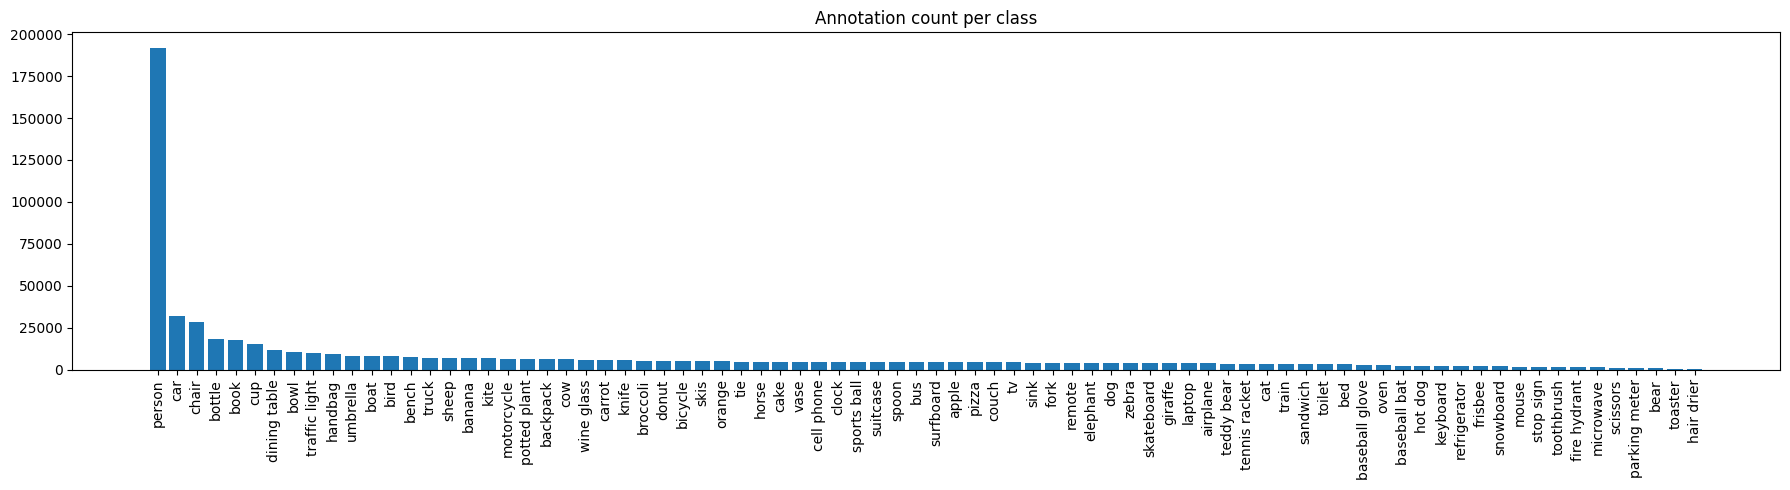

In [2]:
import matplotlib.pyplot as plt
from collections import Counter

# Count annotations per category
cat_id_to_name = {c['id']: c['name'] for c in cats}
ann_counts = Counter(
    cat_id_to_name[ann['category_id']] 
    for ann in coco.anns.values()
)

labels, counts = zip(*sorted(ann_counts.items(), key=lambda x: -x[1]))
plt.figure(figsize=(18, 5))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Annotation count per class")
plt.tight_layout()
plt.show()

In [ ]:
imgs_per_class = {}
for cat in cats:
    img_ids = coco.getImgIds(catIds=[cat['id']])
    imgs_per_class[cat['name']] = len(img_ids)

# Bottom 10 — classes with fewest training images
for name, count in sorted(imgs_per_class.items(), key=lambda x: x[1])[:30]:
    print(f"  {name:<20} {count:>5} images")


  hair drier             145 images
  toaster                166 images
  parking meter          521 images
  scissors               689 images
  bear                   699 images
  toothbrush             739 images
  hot dog                907 images
  donut                 1092 images
  sheep                 1119 images
  microwave             1152 images


In [4]:
import numpy as np

areas = [ann['area'] for ann in coco.anns.values()]
print(f"Median area: {np.median(areas):.0f} px²")
print(f"Mean area:   {np.mean(areas):.0f} px²")

# COCO's own small/medium/large thresholds
small  = sum(1 for a in areas if a < 32**2)
medium = sum(1 for a in areas if 32**2 <= a < 96**2)
large  = sum(1 for a in areas if a >= 96**2)
total  = len(areas)
print(f"Small  (<32²):        {small/total*100:.1f}%")
print(f"Medium (32²–96²):     {medium/total*100:.1f}%")
print(f"Large  (>96²):        {large/total*100:.1f}%")

Median area: 1692 px²
Mean area:   12015 px²
Small  (<32²):        41.5%
Medium (32²–96²):     34.3%
Large  (>96²):        24.2%


## View Samples

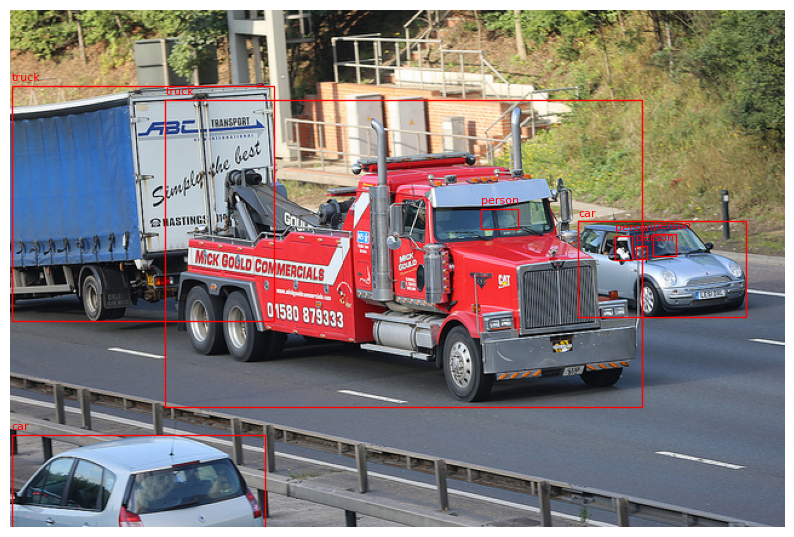

In [21]:
import matplotlib.patches as patches
from PIL import Image
import random

img_id = random.choice(list(coco.imgs.keys()))
img_info = coco.loadImgs(img_id)[0]
ann_ids  = coco.getAnnIds(imgIds=img_id)
anns     = coco.loadAnns(ann_ids)

img = Image.open(f"../coco_dataset/split/images/train/{img_info['file_name'].split('/')[-1]}")

fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(img)
for ann in anns:
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 4, cat_id_to_name[ann['category_id']], color='red', fontsize=8)
plt.axis('off')
plt.show() 